### Homework 2: Supervised Learning
### Name: Shuxiong Cai

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression


### Part A Regression on California test scores

1. Find the url for the California Test Score Data Set from the following website: https://vincentarelbundock.github.io/Rdatasets/datasets.htmlLinks to an external site.. Read through the "DOC" file to understand the variables in the dataset, then use the following url to import the data: https://vincentarelbundock.github.io/Rdatasets/csv/Ecdat/Caschool.csvLinks to an external site.. The target data (i.e. the dependent variable) is named "testscr". You can use all variables in the data except for "readscr" and "mathscr" in the following analysis (those two variables were used to generate the dependent variable). 
2. Pick 3 continuous variables from the data that you think are likely to have a relationship with the target feature. Visualize the univariate distribution of the target feature and each of these three explanatory variables.   
3. Visualize the dependency of the target on each feature you just plotted.
4. Build a KNN Regression model that evaluates the relationship between the target variable and all of the quantitative features (enrltot, teachers, calwpct, mealpct, computer, compstu, expnstu, str, avginc, & elpct). Make sure that you first split the data into training and test sets and tune the hyperparameters where possible using GridSearchCV. Run one version with StandardScaler and one version without it.
5. Repeat Question 4 three more times, each time using one of the linear models that we have learned for regression: Linear Regression (without regularization), Ridge Regression, & Lasso Regression.
6. How different are the results of your 4 models? What impact does StandardScalar make? Discuss which final model you would choose to predict new data & why.
7. Compare the coefficients of your two best linear models (not KNN). Do they agree on which features are important?

In [4]:
df = pd.read_csv('https://vincentarelbundock.github.io/Rdatasets/csv/Ecdat/Caschool.csv')
df.head()

,rownames,distcod,county,district,grspan,enrltot,teachers,calwpct,mealpct,computer,testscr,compstu,expnstu,str,avginc,elpct,readscr,mathscr
0,1,75119,Alameda,Sunol Glen Unified,KK-08,195,10.900000,0.510200,2.040800,67,690.799988,0.343590,6384.911133,17.889910,22.690001,0.000000,691.599976,690.000000
1,2,61499,Butte,Manzanita Elementary,KK-08,240,11.150000,15.416700,47.916698,101,661.200012,0.420833,5099.380859,21.524664,9.824000,4.583333,660.500000,661.900024
2,3,61549,Butte,Thermalito Union Elementary,KK-08,1550,82.900002,55.032299,76.322601,169,643.599976,0.109032,5501.954590,18.697226,8.978000,30.000002,636.299988,650.900024
3,4,61457,Butte,Golden Feather Union Elementary,KK-08,243,14.000000,36.475399,77.049202,85,647.700012,0.349794,7101.831055,17.357143,8.978000,0.000000,651.900024,643.500000
4,5,61523,Butte,Palermo Union Elementary,KK-08,1335,71.500000,33.108601,78.427002,171,640.849976,0.128090,5235.987793,18.671329,9.080333,13.857677,641.799988,639.900024


#### Part A q2

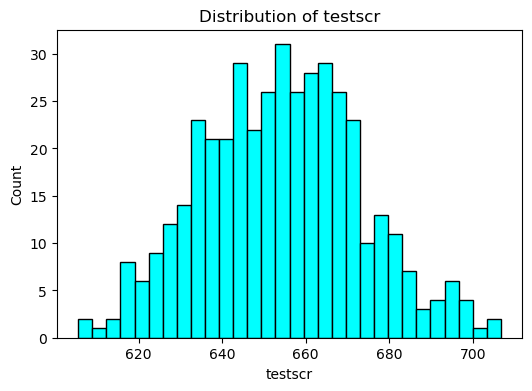

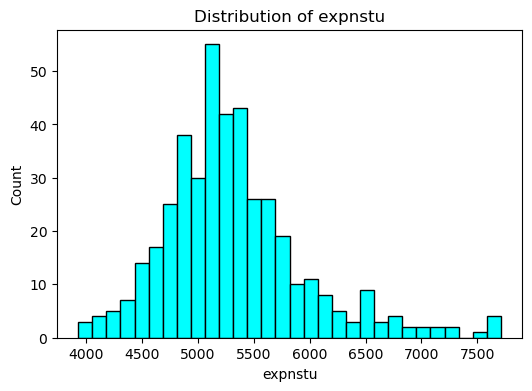

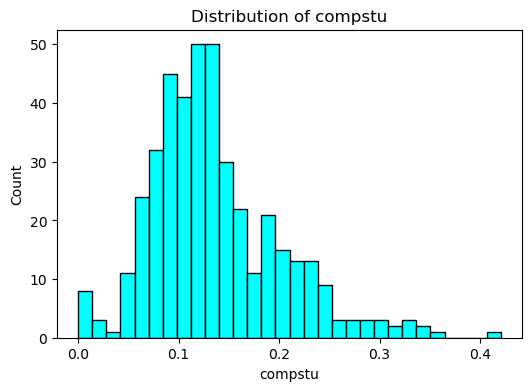

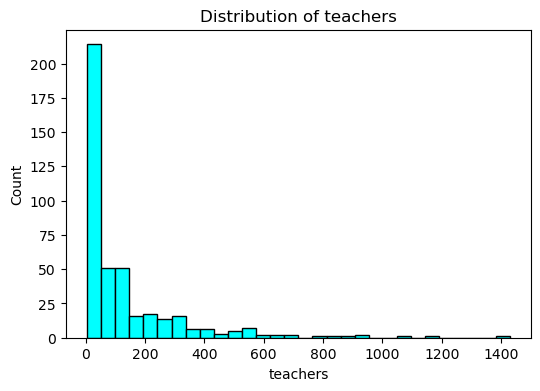

In [6]:
features = ['expnstu', 'compstu', 'teachers']

for col in ['testscr'] + features:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30, color='cyan', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


#### Part A q3

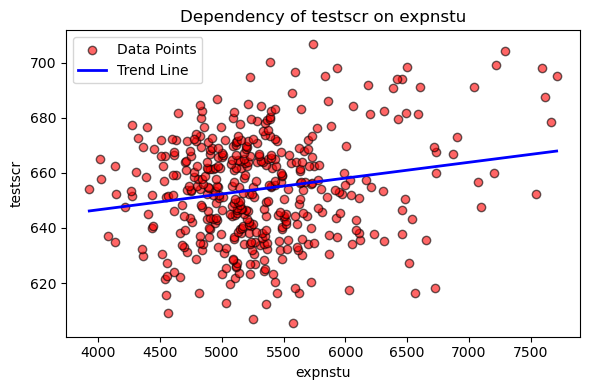

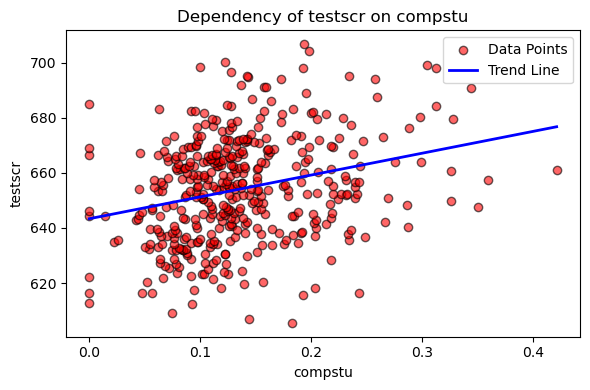

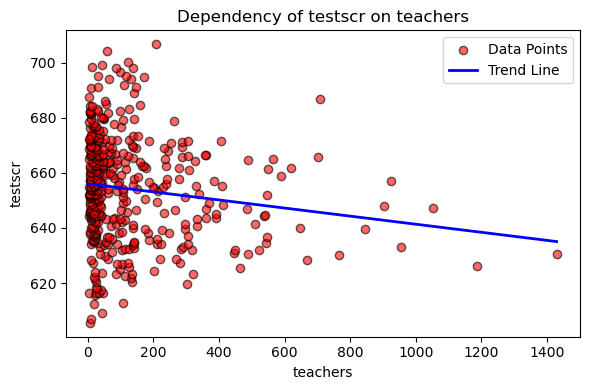

In [8]:
for col in features:
    x = df[col].values
    y = df['testscr'].values
    coeffs = np.polyfit(x, y, 1)
    trend = np.poly1d(coeffs)
    xs = np.linspace(x.min(), x.max(), 200)
    plt.figure(figsize=(6,4))
    plt.scatter(x, y, alpha=0.6, color='red', edgecolor='black', label='Data Points')
    plt.plot(xs, trend(xs), color='blue', linewidth=2, label='Trend Line')
    plt.title(f'Dependency of testscr on {col}')
    plt.xlabel(col)
    plt.ylabel('testscr')
    plt.legend()
    plt.tight_layout()
    plt.show()

#### Part A q4

In [10]:
features = ['enrltot','teachers','calwpct','mealpct',
            'computer','compstu','expnstu','str','avginc','elpct']
X = df[features]
y = df['testscr']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

results = [] 

# without stardard scaler
knn_pipe_no = Pipeline([('kneighborsregressor', KNeighborsRegressor())])
param_grid_no = {'kneighborsregressor__n_neighbors': range(1, 10)}
grid_no = GridSearchCV(knn_pipe_no, param_grid_no, cv=10)  
grid_no.fit(X_train, y_train)

print(grid_no.best_params_)
print(grid_no.score(X_test, y_test))

{'kneighborsregressor__n_neighbors': 6}
0.09522356893161055


In [11]:
# with stardard scaler
knn_pipe = Pipeline([('scaler', StandardScaler()),('kneighborsregressor', KNeighborsRegressor())])
param_grid = {'kneighborsregressor__n_neighbors': range(1, 10)}
grid = GridSearchCV(knn_pipe, param_grid, cv=10)  
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.score(X_test, y_test))

{'kneighborsregressor__n_neighbors': 8}
0.8001608406158836


#### Part A q5

In [13]:
# Linear Regression(no standard scale)
lr = LinearRegression().fit(X_train, y_train)
print("lr.coef_(without sc): {}".format(lr.coef_))
print("Training set score: {:.3f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.3f}".format(lr.score(X_test, y_test)))

lr.coef_(without sc): [ 6.58067660e-04 -1.83945934e-02 -6.62885918e-02 -3.96103967e-01
  2.35178372e-03 -3.36696148e+00  1.38678940e-03 -6.88003009e-01
  4.96721632e-01 -1.78153524e-01]
Training set score: 0.806
Test set score: 0.802


In [14]:
# Linear Regression(+ standard scale)
pipe_lr = Pipeline([('scaler', StandardScaler()),('linear', LinearRegression())]).fit(X_train, y_train)

print("lr.coef_ (+scaler): {}".format(pipe_lr.named_steps['linear'].coef_))
print("Training set score (+scaler): {:.3f}".format(pipe_lr.score(X_train, y_train)))
print("Test set score (+scaler): {:.3f}".format(pipe_lr.score(X_test, y_test)))

lr.coef_ (+scaler): [  2.71770027  -3.64405536  -0.73237476 -10.70038703   1.09097767
  -0.21630334   0.85364775  -1.2611852    3.51568487  -3.17898417]
Training set score (+scaler): 0.806
Test set score (+scaler): 0.802


In [15]:
# Ridge Regression(no standard scale)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
print("ridge.coef_(without sc): {}".format(ridge.coef_))
print("Training set score: {:.3f}".format(ridge.score(X_train, y_train)))
print("Test set score: {:.3f}".format(ridge.score(X_test, y_test)))

ridge.coef_(without sc): [ 6.13376981e-04 -1.67653496e-02 -6.48678590e-02 -3.96903276e-01
  2.05486142e-03 -1.63578075e+00  1.36379301e-03 -6.74713283e-01
  4.95881586e-01 -1.76974666e-01]
Training set score: 0.806
Test set score: 0.803


In [16]:
# Ridge Regression(+ standard scale)
pipe_ridge = Pipeline([('scaler', StandardScaler()),('ridge', Ridge(alpha=1.0))]).fit(X_train, y_train)

print("ridge.coef_ (+scaler): {}".format(pipe_ridge.named_steps['ridge'].coef_))
print("Training set score (+scaler): {:.3f}".format(pipe_ridge.score(X_train, y_train)))
print("Test set score (+scaler): {:.3f}".format(pipe_ridge.score(X_test, y_test)))

ridge.coef_ (+scaler): [  0.78511408  -1.55474308  -0.81653887 -10.57243931   0.91678774
  -0.18966323   0.86611492  -1.1797934    3.52809925  -3.22763789]
Training set score (+scaler): 0.806
Test set score (+scaler): 0.803


In [17]:
# Lasso Regression(no standard scale)
lasso = Lasso(alpha=1.0, max_iter=100000).fit(X_train, y_train)

print("lasso.coef_(without sc): {}".format(lasso.coef_))
print("Training set score: {:.3f}".format(lasso.score(X_train, y_train)))
print("Test set score: {:.3f}".format(lasso.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso.coef_ != 0)))

lasso.coef_(without sc): [-0.00049317  0.00632373 -0.04774995 -0.41480182  0.0014819  -0.
  0.00231912 -0.06884393  0.45770375 -0.16582408]
Training set score: 0.804
Test set score: 0.809
Number of features used: 9


In [18]:
# Lasso Regression(+ standard scale)
pipe_lasso = Pipeline([('scaler', StandardScaler()),('lasso', Lasso(alpha=1.0, max_iter=100000))]).fit(X_train, y_train)
lasso_scaled = pipe_lasso.named_steps['lasso']

print("lasso.coef_ (+scaler): {}".format(lasso_scaled.coef_))
print("Training set score (+scaler): {:.3f}".format(pipe_lasso.score(X_train, y_train)))
print("Test set score (+scaler): {:.3f}".format(pipe_lasso.score(X_test, y_test)))
print("Number of features used (+scaler): {}".format(np.sum(lasso_scaled.coef_ != 0)))


lasso.coef_ (+scaler): [ -0.          -0.          -0.         -11.15582252  -0.
   0.           0.17669259  -0.694751     3.13902511  -2.30443527]
Training set score (+scaler): 0.799
Test set score (+scaler): 0.783
Number of features used (+scaler): 5


#### Part A q6
As the above result shows: KNN: 0.095 → 0.800, Linear (OLS): 0.802 → 0.802, Ridge (α=1): 0.803 → 0.803, Lasso (α=1): 0.809 → 0.783
Impact of StandardScaler: It’s important for KNN (0.095 → 0.800 ) because it is sensitive for the distance-base model. For Linear regression and lasso regression and ridge regession not no significant impact.
Final model: I would use “StandardScaler + Lasso/Ridge and tuned α. I guess if re-tune α, the final answer will more stable.

#### PartA q7

According to the coefficient data, the two best linear models are Ridge and Lasso. The important features are avginc, str, mealpct, elpct. Because they are consistent across both.

### Part B: Classification on red and white wine characteristics
1. First, import the red and the white wine csv files into separate pandas dataframes from the following website. Note that you’ll need to adjust the argument for read_csv() from sep=',' to sep=';' (https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csvLinks to an external site.) (https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csvLinks to an external site.)
2. Add a new column to each dataframe called "winetype". For the white wine dataset, label the values in this column with a 0, indicating white wine. For the red wine dataset, label values with a 1, indicating red wine. Combine both datasets into a single dataframe. The target data (i.e. the dependent variable) is "winetype".
3. Pick 3 continuous variables from the data that you think are likely to have a relationship with the target feature. Visualize the univariate distribution of the target feature and each of these three explanatory variables.   
4. Build a KNN Classification model that evaluates the relationship between the target variable and the 3 features you selected in Question 3. Make sure that you first split the data into training and test sets and tune the hyperparameters where possible using GridSearchCV. Run one version with StandardScaler and one version without it.
5. Repeat Question 4 two more times, each time using a different linear model that we have learned for classification: Logistic Regression with no regularization, and Logistic Regression with L2 regularization.
6. How different are the results of your 3 models? What impact does StandardScalar make? Discuss which final model you would choose to predict new data & why.
7. Compare the coefficients for Logistic Regression with and without regularization. Do they agree on which features are important?

#### PartB q1

In [24]:
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
url_red   = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df_white = pd.read_csv(url_white, sep=';')
df_red   = pd.read_csv(url_red,   sep=';')

In [25]:
df_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [26]:
df_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


#### PartB q2

In [28]:
df_white['winetype'] = 0
df_red['winetype']   = 1

wine = pd.concat([df_white, df_red], ignore_index=True)
y = wine['winetype']             
X = wine.drop(columns=['winetype']) 

#### PartB q3

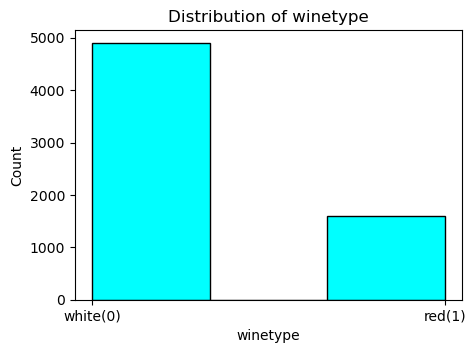

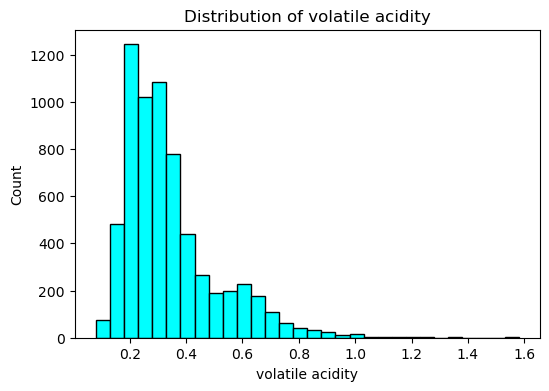

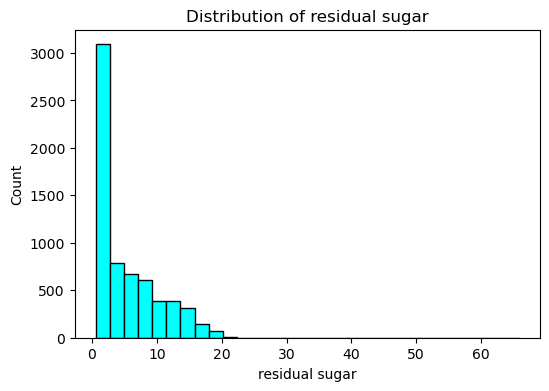

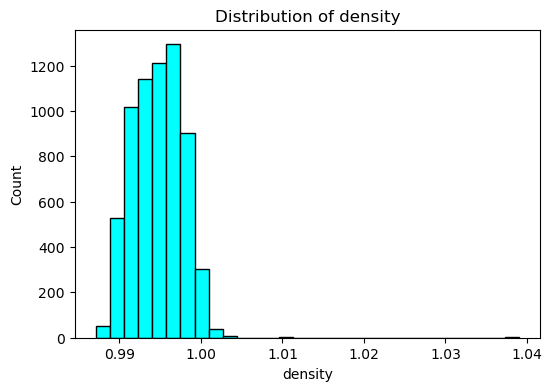

In [30]:
feature_B = ['volatile acidity', 'residual sugar', 'density']

plt.figure(figsize=(5,3.5))
plt.hist(wine['winetype'], bins=3,color='cyan', edgecolor='black')
plt.xticks([0,1], ['white(0)','red(1)'])
plt.title('Distribution of winetype')
plt.xlabel('winetype')
plt.ylabel('Count')
plt.show()

for col in feature_B:
    plt.figure(figsize=(6,4))
    plt.hist(wine[col], bins=30,color='cyan', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()



#### Part B q4


In [32]:
X_B = wine[feature_B].copy()
y_B = wine['winetype']  

X_train, X_test, y_train, y_test = train_test_split(X_B, y_B, test_size=0.20, random_state=42)

# without standard scaler
b_knn_pipe_no = Pipeline([('kneighborsclassifier', KNeighborsClassifier())])
b_param_no = {'kneighborsclassifier__n_neighbors': range(1, 10)} 
b_grid_no = GridSearchCV(b_knn_pipe_no, b_param_no, cv=10) 
b_grid_no.fit(X_train, y_train)

print(b_grid_no.best_params_)
print(b_grid_no.score(X_test, y_test))



{'kneighborsclassifier__n_neighbors': 1}
0.933076923076923


In [33]:
#with Standard Scaler 

b_knn_pipe_sc = Pipeline([('scaler', StandardScaler()),('kneighborsclassifier', KNeighborsClassifier())])
b_param_sc = {'kneighborsclassifier__n_neighbors': range(1, 10)} 
b_grid_sc = GridSearchCV(b_knn_pipe_sc, b_param_sc, cv=10, n_jobs=-1)
b_grid_sc.fit(X_train, y_train)

print( b_grid_sc.best_params_)
print( b_grid_sc.score(X_test, y_test))




{'kneighborsclassifier__n_neighbors': 8}
0.9684615384615385


#### Part B q5

In [35]:
# Logistic Regression with no regularization 
# without standard scaler
logit_none = LogisticRegression(penalty=None).fit(X_train, y_train)
print("logit .coef_: {}".format(logit_none.coef_))
print("Training set score: {:.3f}".format(logit_none.score(X_train, y_train)))
print("Test set score: {:.3f}".format(logit_none.score(X_test, y_test)))

predicted_vals = logit_none.predict(X_test)  
print("logit.predict: {}".format(predicted_vals))


logit .coef_: [[ 1.01279084e+01 -9.97128960e-01  1.33423114e+03]]
Training set score: 0.963
Test set score: 0.961
logit.predict: [0 0 0 ... 1 1 1]


In [36]:
# Logistic Regression with no regularization 
# with standard scaler
pipe_logit_none = Pipeline([('scaler', StandardScaler()),('logit', LogisticRegression(penalty=None))]).fit(X_train, y_train)

print("\n[+Scaler] logit .coef_: {}".format(pipe_logit_none.named_steps['logit'].coef_))
print("Training set score (+scaler): {:.3f}".format(pipe_logit_none.score(X_train, y_train)))
print("Test set score (+scaler): {:.3f}".format(pipe_logit_none.score(X_test, y_test)))

predicted_vals_sc = pipe_logit_none.predict(X_test)
print("logit.predict (+scaler): {}".format(predicted_vals_sc))



[+Scaler] logit .coef_: [[ 1.68020769 -4.76827169  4.01072584]]
Training set score (+scaler): 0.963
Test set score (+scaler): 0.961
logit.predict (+scaler): [0 0 0 ... 1 1 1]


In [37]:
# Logistic Regression with L2 regularization 
# without standard scaler
logit_l2 = LogisticRegression(C=1.0, penalty='l2').fit(X_train, y_train)
print("\n[L2] logit .coef_: {}".format(logit_l2.coef_))
print("Training set score: {:.3f}".format(logit_l2.score(X_train, y_train)))
print("Test set score: {:.3f}".format(logit_l2.score(X_test, y_test)))
print("logit.predict:", logit_l2.predict(X_test))


[L2] logit .coef_: [[11.28945898 -0.41340399  2.05706826]]
Training set score: 0.886
Test set score: 0.894
logit.predict: [0 0 0 ... 0 1 1]


In [38]:
# Logistic Regression with L2 regularization 
# with standard scaler
pipe_logit_l2 = Pipeline([('scaler', StandardScaler()),('logit', LogisticRegression(C=1.0, penalty='l2'))]).fit(X_train, y_train)
print("\n[L2 + scaler] logit .coef_: {}".format(pipe_logit_l2.named_steps['logit'].coef_))
print("Training set score (+scaler): {:.3f}".format(pipe_logit_l2.score(X_train, y_train)))
print("Test set score (+scaler): {:.3f}".format(pipe_logit_l2.score(X_test, y_test)))
print("logit.predict (+scaler):", pipe_logit_l2.predict(X_test))


[L2 + scaler] logit .coef_: [[ 1.63463312 -4.47685862  3.78939613]]
Training set score (+scaler): 0.962
Test set score (+scaler): 0.962
logit.predict (+scaler): [0 0 0 ... 1 1 1]


#### PartB q6

Result: KNN no scaler 0.933 → +scaler 0.968 (small increase), Logistic (no penalty, no scaler) 0.961 →(no penalty, +scaler) 0.961 (no change), Logistic (L2, no scaler) 0.894 → (L2, +scaler) 0.962 (bid increase).
Impact of StandardScalar: it matters a lot for KNN, because it make neighborhoods are more stable and Significant improvement in accuracy. But it did not impact of Logistic (no penalty). Last Logistic regression (L2) has the most significant impact.
After scaling, the penalty terms are distributed fairly among features, coefficients stabilize, and generalization is significantly enhanced.
The final model, I will select KNN + StandardScaler (0.968). Because it has the highest accuracy

#### PartB q7

Using the scaled runs, coefficients are very similar: volatile acidity positive, residual sugar negative, density positive.
They agree on signs and relative importance (residual sugar is the largest, then density, last volatile acidity).